# GridSearch over `QuantileReg` on California housing

Tune two LightGBM hyperparameters using bracketlearn's own time-aware
CV inside each grid point (sklearn's `GridSearchCV` would silently
destroy time ordering for sequential data).

Then a **leaderboard** of competing model families benchmarked against
the grid winner — does tuning `QuantileReg` beat untuned alternatives?

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd() / "_src"))

import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import RidgeCV

warnings.filterwarnings(
    "ignore", message="X does not have valid feature names.*",
    category=UserWarning,
)

from bracketlearn.baselines import EmpiricalDistribution
from bracketlearn.composite import LiftedForecaster
from bracketlearn.lift import GlobalResidual
from bracketlearn.pipeline import ForecastPipeline
from bracketlearn.score import to_point
from bracketlearn.search import GridSearch
from bracketlearn.trainers import (
    NGBoostNormal,
    QuantileForest,
    QuantileReg,
    SklearnPoint,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error

from _style import (
    color_for, predicted_vs_realized_grid, leaderboard_bar,
)
import matplotlib.pyplot as plt

## Data + baseline

In [2]:
data = fetch_california_housing()
X = np.asarray(data.data, dtype=float)
y = np.asarray(data.target, dtype=float)
rng = np.random.default_rng(0)
keep = rng.choice(X.shape[0], size=3000, replace=False)
X, y = X[keep], y[keep]
ids = np.arange(X.shape[0])
ts = ids.astype(float)
print(f"X shape {X.shape}, y range ${y.min()*100:.0f}k–${y.max()*100:.0f}k")

X shape (3000, 8), y range $18k–$500k


In [3]:
base_pipeline = ForecastPipeline(
    steps=[("emp", EmpiricalDistribution())],
    cv="kfold", n_folds=4, shuffle=True, random_state=0,
    refit_on_full=False,
)
base_result = base_pipeline.fit_predict(X, y, ids=ids, timestamps=ts)
baseline_crps = base_result.score(y, metrics=["crps"])["emp"]["crps"]
print(f"baseline Empirical CRPS = {baseline_crps:.4f}")

baseline Empirical CRPS = 0.6107


## Grid: 3 × 3 over (n_estimators, learning_rate)

In [4]:
prototype = ForecastPipeline(
    steps=[("qreg", QuantileReg(random_seed=0))],
    cv="kfold", n_folds=4, shuffle=True, random_state=0,
    refit_on_full=True,
)
n_est_grid = [50, 150, 400]
lr_grid = [0.03, 0.1, 0.2]
grid = {
    "qreg__n_estimators": n_est_grid,
    "qreg__learning_rate": lr_grid,
}
print(f"running GridSearch over {len(n_est_grid) * len(lr_grid)} points …")
search = GridSearch(
    prototype, param_grid=grid,
    scoring="crps", refit_stage="qreg",
)
search.fit(X, y, ids=ids, timestamps=ts)
print(f"best: {search.best_params_}  CRPS={search.best_score_:.4f}")
print(f"baseline CRPS={baseline_crps:.4f}  "
      f"best CRPSS={1-search.best_score_/baseline_crps:+.3f}")

running GridSearch over 9 points …


best: {'qreg__n_estimators': 400, 'qreg__learning_rate': 0.1}  CRPS=0.2501
baseline CRPS=0.6107  best CRPSS=+0.590


## Grid landscape — heatmap with annotated cells

The cell value is CRPS (lower is better). The winning cell is outlined
in black. Cells far from the winner give you a sense of how flat (or
steep) the loss surface is around the optimum.

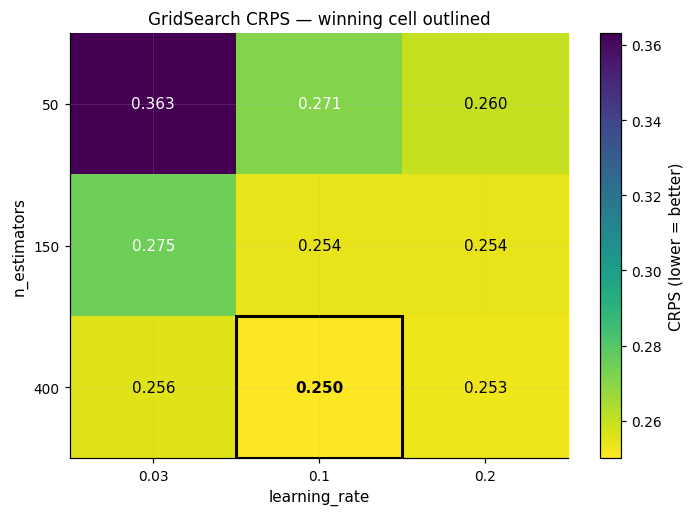

In [5]:
crps_matrix = np.full((len(n_est_grid), len(lr_grid)), np.nan)
for row in search.results_:
    n_est = row["params"]["qreg__n_estimators"]
    lr = row["params"]["qreg__learning_rate"]
    i = n_est_grid.index(n_est)
    j = lr_grid.index(lr)
    crps_matrix[i, j] = row["crps"]

best_i, best_j = np.unravel_index(np.argmin(crps_matrix), crps_matrix.shape)

fig, ax = plt.subplots(figsize=(6.5, 4.8))
im = ax.imshow(crps_matrix, cmap="viridis_r", aspect="auto")
for i in range(len(n_est_grid)):
    for j in range(len(lr_grid)):
        is_best = (i, j) == (best_i, best_j)
        val = crps_matrix[i, j]
        color = "white" if val > crps_matrix.mean() else "black"
        ax.text(j, i, f"{val:.3f}",
                ha="center", va="center", color=color,
                fontweight="bold" if is_best else "regular")
# Outline the winning cell.
ax.add_patch(plt.Rectangle((best_j - 0.5, best_i - 0.5), 1, 1,
                            fill=False, edgecolor="black", lw=2.0))
ax.set_xticks(range(len(lr_grid)), labels=[str(lr) for lr in lr_grid])
ax.set_yticks(range(len(n_est_grid)), labels=[str(n) for n in n_est_grid])
ax.set_xlabel("learning_rate")
ax.set_ylabel("n_estimators")
ax.set_title("GridSearch CRPS — winning cell outlined")
fig.colorbar(im, ax=ax, label="CRPS (lower = better)")
fig.tight_layout()
plt.show()

## Grid landscape — dot plot

An alternative view: every grid point as a labeled dot in (lr, CRPS)
space, with curves connecting points that share `n_estimators`. Shows
the marginal effect of each hyperparameter without the heatmap's
discretisation.

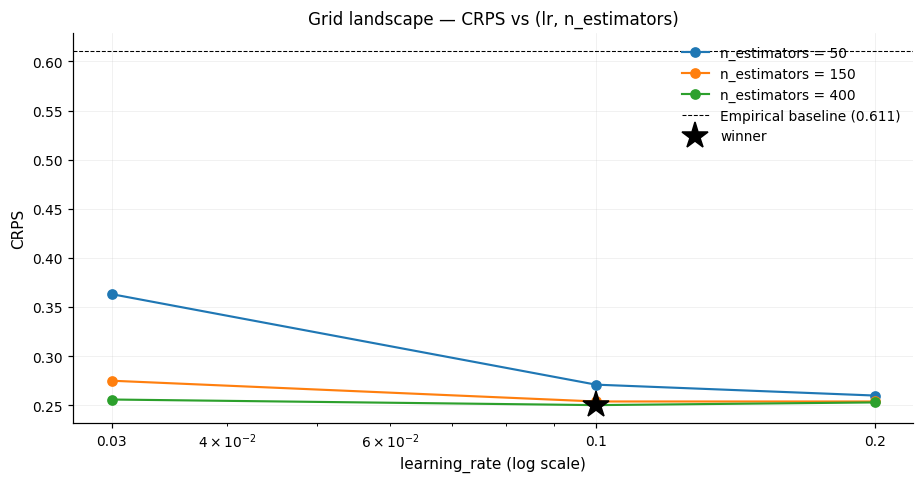

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for i, n_est in enumerate(n_est_grid):
    crps_at_n = crps_matrix[i]
    ax.plot(lr_grid, crps_at_n, marker="o", lw=1.4,
            color=color_for(f"n={n_est}", fallback_index=i),
            label=f"n_estimators = {n_est}")
ax.axhline(baseline_crps, color="black", linestyle="--", lw=0.7,
           label=f"Empirical baseline ({baseline_crps:.3f})")
# Highlight the winning point.
winner_lr = lr_grid[best_j]
winner_crps = crps_matrix[best_i, best_j]
ax.plot(winner_lr, winner_crps, marker="*", markersize=18,
        color="black", linestyle="none", label="winner")
ax.set_xscale("log")
ax.set_xticks(lr_grid, labels=[str(lr) for lr in lr_grid])
ax.set_xlabel("learning_rate (log scale)")
ax.set_ylabel("CRPS")
ax.set_title("Grid landscape — CRPS vs (lr, n_estimators)")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

## Predicted vs realized — best pipeline on a held-out slice

`best_pipeline_` is already refit on the full training data. Predict
on a held-out 200-row slice and show the headline scatter.

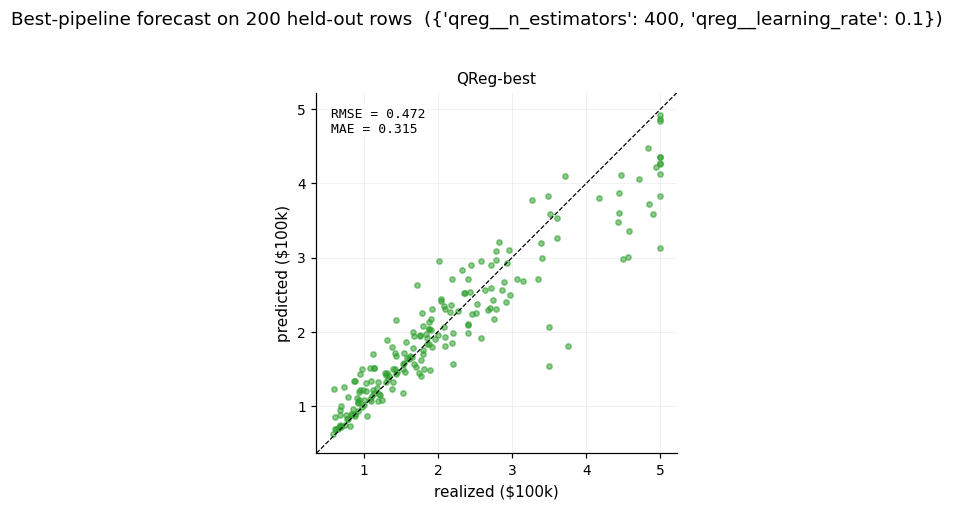

In [7]:
test_idx = rng.choice(X.shape[0], size=200, replace=False)
pred = search.best_pipeline_.predict(
    X[test_idx], ids=np.arange(test_idx.size),
    timestamps=np.arange(test_idx.size, dtype=float),
)["qreg"]
mu = to_point(pred, how="mean")
y_true = y[test_idx]
fig = predicted_vs_realized_grid(
    [("QReg-best", mu, y_true, {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, mu))),
        "MAE":  float(mean_absolute_error(y_true, mu)),
    })],
    ncols=1, units="$100k",
    figsize_per_panel=(4.5, 4.5),
    title=f"Best-pipeline forecast on 200 held-out rows  ({search.best_params_})",
)
plt.show()

## Quantile-fan view of the same predictions

Sort by the *single feature* with the highest correlation with price
(almost always `MedInc` on this dataset) and draw the 10–90 % band as
a function of that feature.

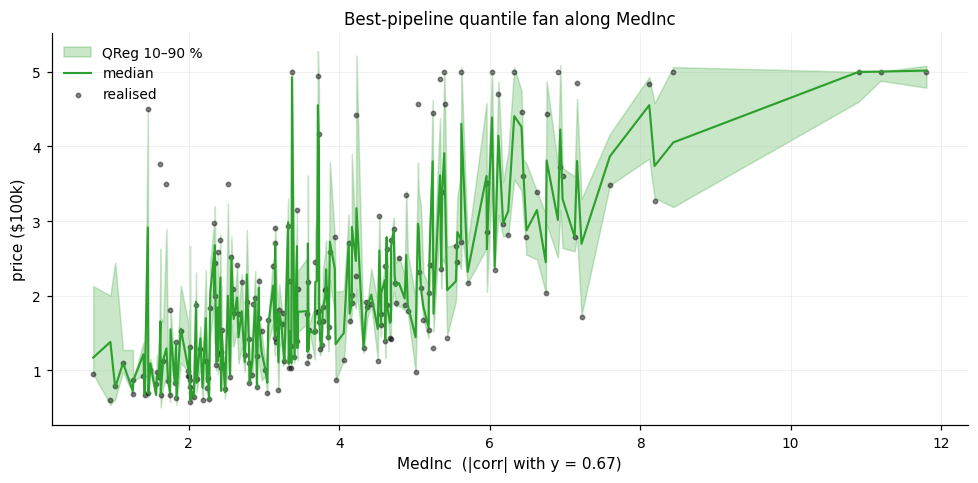

In [8]:
taus = pred.taus
i_lo, i_md, i_hi = (np.argmin(np.abs(taus - q)) for q in (0.1, 0.5, 0.9))
corrs = np.array([abs(np.corrcoef(X[test_idx, j], y_true)[0, 1])
                  for j in range(X.shape[1])])
fi = int(np.argmax(corrs))
xf = X[test_idx, fi]
order = np.argsort(xf)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.fill_between(xf[order], pred.qvals[order, i_lo], pred.qvals[order, i_hi],
                alpha=0.25, color=color_for("QReg-best"),
                label="QReg 10–90 %")
ax.plot(xf[order], pred.qvals[order, i_md], color=color_for("QReg-best"),
        lw=1.4, label="median")
ax.scatter(xf, y_true, s=8, color="black", alpha=0.45, label="realised")
ax.set_xlabel(f"{data.feature_names[fi]}  (|corr| with y = {corrs[fi]:.2f})")
ax.set_ylabel("price ($100k)")
ax.set_title(f"Best-pipeline quantile fan along {data.feature_names[fi]}")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

## Leaderboard: competing model families

Tuned `QuantileReg` vs untuned alternatives, all on the same k-fold
split.

rank model                       CRPS     CRPSS
-----------------------------------------------
1    QReg-best                 0.2501    +0.590
2    QuantileForest            0.2840    +0.535
3    NGBoostNormal             0.3471    +0.432
4    Ridge+GR                  0.4155    +0.320
5    Empirical                 0.6107    +0.000


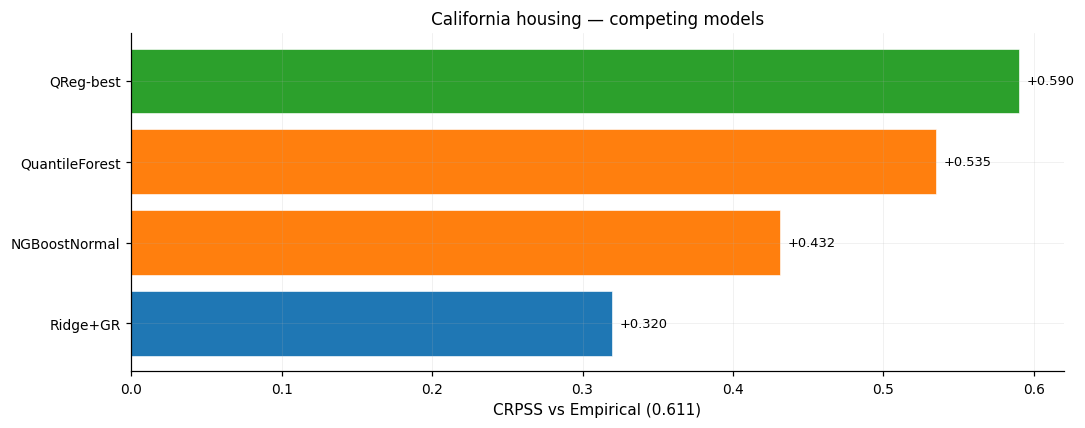

In [9]:
def _score_full(stage_name, forecaster):
    p = ForecastPipeline(
        steps=[(stage_name, forecaster)],
        cv="kfold", n_folds=4, shuffle=True, random_state=0,
        refit_on_full=False,
    )
    r = p.fit_predict(X, y, ids=ids, timestamps=ts)
    return r.score(y, metrics=["crps"])[stage_name]["crps"]


lb = {
    "Empirical":           baseline_crps,
    "Ridge+GR":            _score_full("ridge", LiftedForecaster(
        SklearnPoint(RidgeCV()), GlobalResidual(), name="ridge",
    )),
    "NGBoostNormal":       _score_full("ngb", NGBoostNormal(
        n_estimators=200, random_seed=0,
    )),
    "QuantileForest":      _score_full("qf", QuantileForest(
        n_estimators=200, random_seed=0,
    )),
    "QReg-best":           search.best_score_,
}

rows = sorted(lb.items(), key=lambda kv: kv[1])
print(f"{'rank':<5}{'model':<22}{'CRPS':>10}{'CRPSS':>10}")
print("-" * 47)
for i, (name, c) in enumerate(rows, 1):
    print(f"{i:<5}{name:<22}{c:>10.4f}{1-c/baseline_crps:>+10.3f}")

fig = leaderboard_bar(
    [(n, v) for n, v in rows],
    baseline_name="Empirical", baseline_value=baseline_crps,
    skill_label="CRPSS",
    title="California housing — competing models",
)
plt.show()

## Point-forecast benchmark

Headline scatter grid: best probabilistic mean vs sklearn baselines.

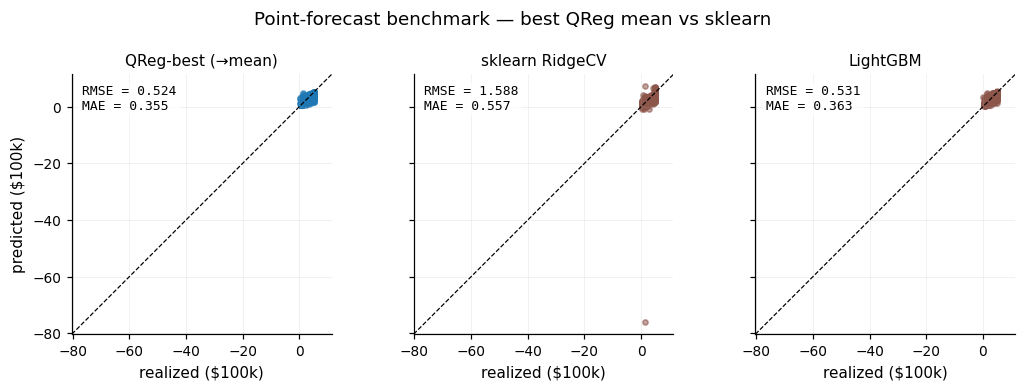

In [10]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold

best_eval = ForecastPipeline(
    steps=[("qreg", QuantileReg(
        n_estimators=search.best_params_["qreg__n_estimators"],
        learning_rate=search.best_params_["qreg__learning_rate"],
        random_seed=0,
    ))],
    cv="kfold", n_folds=4, shuffle=True, random_state=0,
    refit_on_full=False,
).fit_predict(X, y, ids=ids, timestamps=ts)
dist = best_eval["qreg"]
y_oof = y[dist.ids.astype(int)]
mu_best = to_point(dist, how="mean")


def _sklearn_oof(model_factory):
    kf = KFold(n_splits=4, shuffle=True, random_state=0)
    preds = np.empty_like(y)
    for tr, te in kf.split(X):
        m = model_factory()
        m.fit(X[tr], y[tr])
        preds[te] = m.predict(X[te])
    return preds


sk_ridge_pred = _sklearn_oof(lambda: RidgeCV())
sk_lgb_pred = _sklearn_oof(lambda: LGBMRegressor(
    n_estimators=200, learning_rate=0.05, verbose=-1, random_state=0,
))

panels_pt = []
for name, mu_pred, y_ref in [
    ("QReg-best (→mean)", mu_best, y_oof),
    ("sklearn RidgeCV",   sk_ridge_pred, y),
    ("LightGBM",          sk_lgb_pred, y),
]:
    rmse = float(np.sqrt(mean_squared_error(y_ref, mu_pred)))
    mae = float(mean_absolute_error(y_ref, mu_pred))
    panels_pt.append((name, mu_pred, y_ref, {"RMSE": rmse, "MAE": mae}))

fig = predicted_vs_realized_grid(
    panels_pt, ncols=3, units="$100k",
    figsize_per_panel=(3.3, 3.3),
    title="Point-forecast benchmark — best QReg mean vs sklearn",
)
plt.show()